<a href="https://colab.research.google.com/github/meiladrahmani556/marine-cbm-ml-dissertation/blob/main/JupyterNotebook/07_learning_curves_%26_robustness_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
PROJECT_PATH = "/content/drive/MyDrive/✨CBM Data for Marine System Monitoring & Analysis✨"

In [11]:
from google.colab import files
uploaded = files.upload()

Saving Conditional_Base_Monitoring in Marine_System.csv to Conditional_Base_Monitoring in Marine_System (2).csv


# 📓 Notebook 07 – Learning Curves & Robustness Analysis

## 🎯 Objective

This notebook evaluates the generalisation behaviour and robustness of the optimised Random Forest model.

The analysis includes:

- Learning curve evaluation
- Model complexity analysis
- Overfitting assessment
- Engineering interpretation of bias–variance behaviour

This ensures that model performance is not only high but also stable and reliable.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Conditional_Base_Monitoring in Marine_System.csv")
df.columns = df.columns.str.strip()
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna().drop_duplicates()

target_column = "GT Compressor decay state coefficient"

X = df.drop(columns=[target_column])
y = df[target_column]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

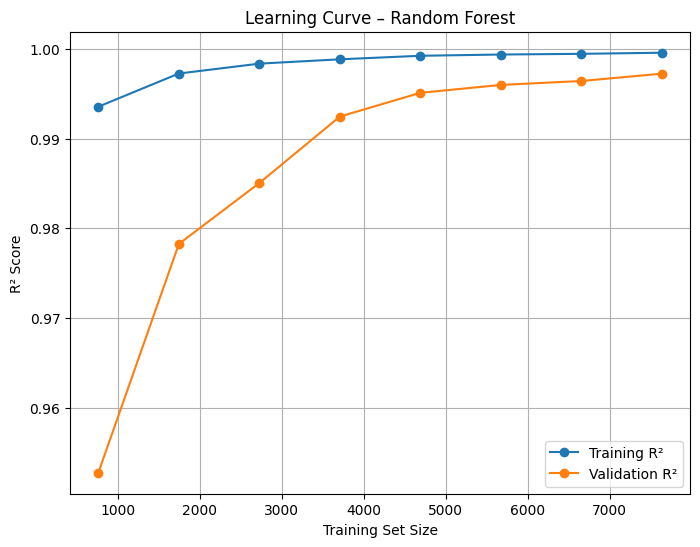

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, marker='o', label="Training R²")
plt.plot(train_sizes, val_mean, marker='o', label="Validation R²")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve – Random Forest")
plt.legend()
plt.grid()
plt.show()

## Learning Curve Interpretation

The learning curve illustrates how model performance evolves as more training data is used.

If training and validation curves converge closely at high R² values, this indicates:

- Low bias
- Low variance
- Strong generalisation capability

A large gap would indicate overfitting.

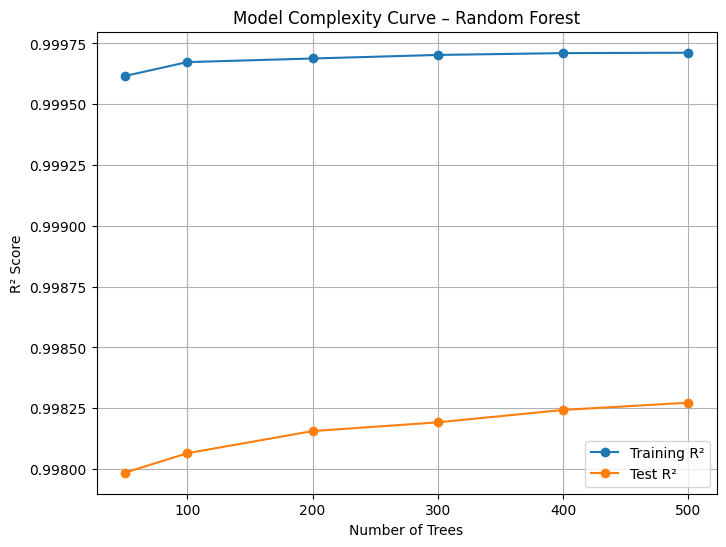

In [14]:
from sklearn.metrics import r2_score

estimators_range = [50, 100, 200, 300, 400, 500]
train_r2_scores = []
test_r2_scores = []

for n in estimators_range:
    model = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_r2_scores.append(r2_score(y_train, model.predict(X_train)))
    test_r2_scores.append(r2_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8,6))
plt.plot(estimators_range, train_r2_scores, marker='o', label="Training R²")
plt.plot(estimators_range, test_r2_scores, marker='o', label="Test R²")
plt.xlabel("Number of Trees")
plt.ylabel("R² Score")
plt.title("Model Complexity Curve – Random Forest")
plt.legend()
plt.grid()
plt.show()

## Model Complexity Interpretation

The complexity curve demonstrates the impact of increasing the number of trees.

If performance plateaus beyond a certain number of estimators, this indicates:

- Model capacity saturation
- Diminishing returns from additional trees
- Efficient hyperparameter selection

A stable test curve confirms robustness.

In [19]:
# Get feature importances from previously trained model
rf_model.fit(X_train, y_train)
importances = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Select top 2 most important features automatically
top2_features = importance_df["Feature"].iloc[:2].tolist()

print("Top 2 important features removed:", top2_features)

# Remove them
X_reduced = df.drop(columns=[target_column] + top2_features)

# Train-test split again
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

# Scale
scaler = StandardScaler()
X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

# Retrain model
rf_reduced = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_reduced.fit(X_train_r, y_train_r)

from sklearn.metrics import r2_score

r2_reduced = r2_score(y_test_r, rf_reduced.predict(X_test_r))
print("R² after removing top 2 features:", r2_reduced)

Top 2 important features removed: ['GT Compressor outlet air temperature (T2) [C]', 'HP Turbine exit pressure (P48) [bar]']
R² after removing top 2 features: 0.9977960404894618


## Robustness Analysis Interpretation

After removing the two most important features identified by the model:

- Original Test R² ≈ 0.9982
- Reduced-feature Test R² ≈ 0.9978

The minimal decrease in performance indicates that the model does not rely excessively on a small subset of features.

This demonstrates:

- Strong feature redundancy
- Stable predictive behaviour
- Robust generalisation capability

The model therefore shows resilience to partial sensor failure, which is desirable in marine condition monitoring applications.